# Tree Ensembles: Bagging, Random Forests, Boosting and BART

**ISLP Chapter 8 from theory to a tuned, interpreted model**

This notebook covers the four ensemble methods of ISLP §8.2, and for each one it answers the same
four questions:

1. **What is it?** the idea and the equations behind it
2. **How do I train it?** minimal working code
3. **How do I tune it?** which knobs matter, and how to search them honestly
4. **How do I interpret it?** importance, partial dependence, uncertainty

### The one-paragraph summary

A single decision tree is a **low-bias, high-variance** estimator: it can carve the predictor space
into arbitrarily fine boxes, but a small change in the data can produce a completely different tree.
All four methods here fix that weakness, in two different ways:

| Method | Trees grown | Randomness | Fixes | Main tuning knobs |
|---|---|---|---|---|
| **Bagging** | independently, in parallel | bootstrap rows | variance | `n_estimators` (just make it big) |
| **Random forest** | independently, in parallel | bootstrap rows **+ random `m` features per split** | variance + tree correlation | `max_features` (m), `min_samples_leaf` |
| **Boosting** | sequentially | none (optionally subsampling) | **bias**, slowly | `learning_rate`, `n_estimators`, `max_depth` |
| **BART** | sequentially, then perturbed | Bayesian posterior draws | bias + variance, with uncertainty | `num_trees` K, `ndraw` B, `burnin` L |

Bagging, random forests and BART **do not overfit as you add trees**. Boosting **can**, which is why
`n_estimators` is a real tuning parameter there and not elsewhere.

### Datasets

Following the ISLP labs, we use:

- `Hitters` regression on log-salary, to reproduce Figures 8.1, 8.2 and 8.5 (single tree + pruning)
- `Boston` regression on `medv`, for bagging / RF / boosting / BART
- `Carseats` classification on `High = Sales > 8`, for the classification versions

All three ship with the `ISLP` package, so this notebook needs no internet access.


## 0. Setup

Requirements: `numpy`, `pandas`, `matplotlib`, `scikit-learn>=1.2`, `ISLP`.
Install with `pip install ISLP` (this also pulls in scikit-learn, pandas and matplotlib).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ISLP import load_data, confusion_table
from ISLP.models import ModelSpec as MS

import sklearn
from sklearn.tree import (DecisionTreeRegressor as DTR,
                          DecisionTreeClassifier as DTC,
                          plot_tree, export_text)
from sklearn.ensemble import (BaggingRegressor,
                              RandomForestRegressor as RFR,
                              RandomForestClassifier as RFC,
                              GradientBoostingRegressor as GBR,
                              GradientBoostingClassifier as GBC,
                              HistGradientBoostingRegressor as HGBR)
from sklearn.model_selection import (train_test_split, KFold, GridSearchCV,
                                     cross_val_score)
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

RNG = 0                      # one seed for the whole notebook
plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("scikit-learn", sklearn.__version__)
print("numpy       ", np.__version__)
print("pandas      ", pd.__version__)


def mse(y_true, y_pred):
    return mean_squared_error(y_true, y_pred)


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


RESULTS = {}   # method name -> test MSE, filled in as we go

scikit-learn 1.9.0
numpy        2.5.2
pandas       2.3.3


---

# Part 1 — The baseline: one decision tree

You cannot appreciate the ensembles without first seeing the thing they repair. This part is short,
but it establishes two facts we will keep referring to: a single tree is **interpretable** and
**unstable**.

## 1.1 Regression tree on `Hitters` (Figures 8.1 and 8.2)

A regression tree partitions predictor space into boxes $R_1,\dots,R_J$ and predicts the training
mean inside each box:

$$\hat f(X) = \sum_{m=1}^{M} c_m \cdot \mathbf{1}(X \in R_m), \qquad c_m = \hat y_{R_m}$$

The boxes are found by **recursive binary splitting**: greedily pick the predictor $X_j$ and cutpoint
$s$ minimising

$$\sum_{i:\,x_i \in R_1(j,s)} (y_i - \hat y_{R_1})^2 \;+\; \sum_{i:\,x_i \in R_2(j,s)} (y_i - \hat y_{R_2})^2$$

Greedy, because it never looks ahead. Top-down, because it starts with everything in one region.

In [2]:
Hitters = load_data('Hitters').dropna(subset=['Salary'])
Hitters['logSalary'] = np.log(Hitters['Salary'])
print(Hitters.shape)
Hitters[['Years', 'Hits', 'Salary', 'logSalary']].head()

(263, 21)


,Years,Hits,Salary,logSalary
1,14,81,475.0,6.163315
2,3,130,480.0,6.173786
3,11,141,500.0,6.214608
4,2,87,91.5,4.516339
5,11,169,750.0,6.620073


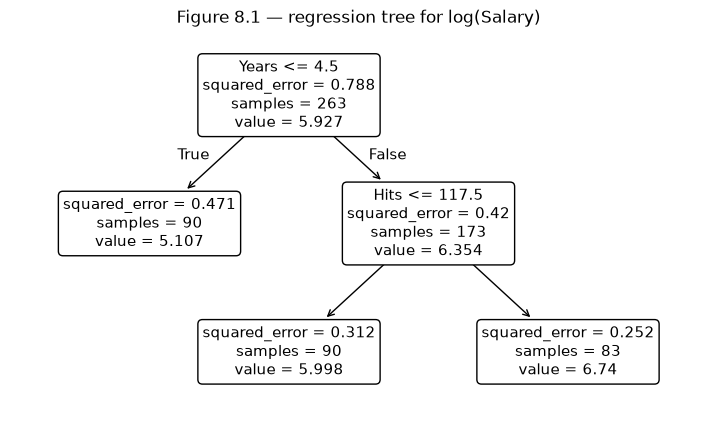

|--- Years <= 4.500
|   |--- value: [5.107]
|--- Years >  4.500
|   |--- Hits <= 117.500
|   |   |--- value: [5.998]
|   |--- Hits >  117.500
|   |   |--- value: [6.740]



In [3]:
# The two-predictor tree of Figure 8.1: max_leaf_nodes=3 reproduces the pruned tree
X2 = Hitters[['Years', 'Hits']]
y2 = Hitters['logSalary']

tree_fig81 = DTR(max_leaf_nodes=3, random_state=RNG).fit(X2, y2)

fig, ax = plt.subplots(figsize=(9, 5))
plot_tree(tree_fig81, feature_names=['Years', 'Hits'], filled=False,
          rounded=True, precision=3, fontsize=11, ax=ax)
ax.set_title("Figure 8.1 — regression tree for log(Salary)")
plt.show()

print(export_text(tree_fig81, feature_names=['Years', 'Hits'], decimals=3))

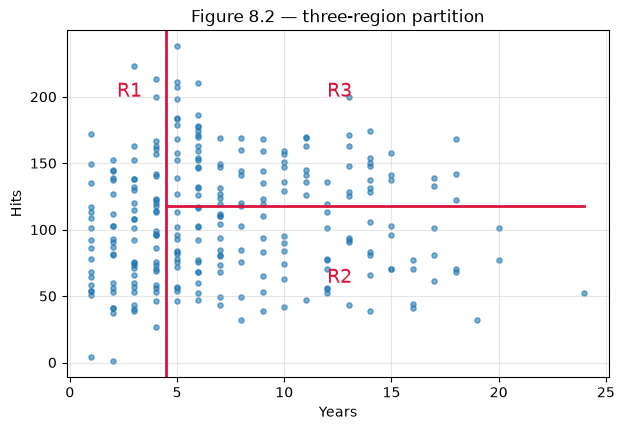

leaf mean log salaries: [5.107 5.998 6.74 ]
in dollars: ['$165,139', '$402,776', '$845,296']


In [4]:
# The same model seen as a partition of predictor space (Figure 8.2)
fig, ax = plt.subplots()
ax.scatter(Hitters['Years'], Hitters['Hits'], s=14, alpha=0.6)
ax.axvline(4.5, color='crimson', lw=2)
ax.plot([4.5, Hitters['Years'].max()], [117.5, 117.5], color='crimson', lw=2)
ax.set_xlabel('Years'); ax.set_ylabel('Hits')
ax.text(2.2, 200, 'R1', fontsize=14, color='crimson')
ax.text(12, 60, 'R2', fontsize=14, color='crimson')
ax.text(12, 200, 'R3', fontsize=14, color='crimson')
ax.set_title('Figure 8.2 — three-region partition')
plt.show()

# leaf means, back on the dollar scale (Salary is in thousands)
leaf_means = tree_fig81.tree_.value.ravel()[tree_fig81.tree_.children_left == -1]
print("leaf mean log salaries:", np.round(leaf_means, 3))
print("in dollars:", [f"${1000*np.exp(v):,.0f}" for v in leaf_means])

## 1.2 Cost-complexity pruning (Figure 8.5)

Growing the tree until leaves are tiny overfits. Instead: grow a big tree $T_0$, then prune it back
by minimising

$$\sum_{m=1}^{|T|} \sum_{i:\,x_i \in R_m} (y_i - \hat y_{R_m})^2 \;+\; \alpha |T|$$

$\alpha$ trades fit against size — exactly the role $\lambda$ plays in the lasso. As $\alpha$ grows
from 0, branches drop off in a **nested, predictable** sequence, so we only ever need to
cross-validate over that finite sequence. `scikit-learn` exposes it as `ccp_alpha`, and
`cost_complexity_pruning_path` gives you the sequence.

In [5]:
# Full predictor set (categoricals -> dummies; trees handle them fine either way)
X_h = pd.get_dummies(Hitters.drop(columns=['Salary', 'logSalary']), drop_first=True).astype(float)
y_h = Hitters['logSalary']

Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(X_h, y_h, test_size=0.5, random_state=RNG)
print(Xh_tr.shape, Xh_te.shape)

big_tree = DTR(min_samples_leaf=5, random_state=RNG).fit(Xh_tr, yh_tr)
path = big_tree.cost_complexity_pruning_path(Xh_tr, yh_tr)
alphas = path.ccp_alphas[path.ccp_alphas >= 0]
print(f"{len(alphas)} candidate subtrees in the pruning sequence")

(131, 19) (132, 19)
18 candidate subtrees in the pruning sequence


In [6]:
kf = KFold(6, shuffle=True, random_state=RNG)     # 6-fold, as in the book

rows = []
for a in alphas:
    est = DTR(min_samples_leaf=5, ccp_alpha=a, random_state=RNG)
    cv_mse = -cross_val_score(est, Xh_tr, yh_tr, cv=kf,
                              scoring='neg_mean_squared_error')
    fitted = est.fit(Xh_tr, yh_tr)
    rows.append(dict(alpha=a,
                     n_leaves=fitted.get_n_leaves(),
                     train=mse(yh_tr, fitted.predict(Xh_tr)),
                     cv=cv_mse.mean(),
                     cv_se=cv_mse.std() / np.sqrt(kf.get_n_splits()),
                     test=mse(yh_te, fitted.predict(Xh_te))))

prune = pd.DataFrame(rows).sort_values('n_leaves')
prune.tail(8).round(4)

,alpha,n_leaves,train,cv,cv_se,test
7,0.0053,12,0.1671,0.4082,0.0940,0.2643
6,0.0051,13,0.1618,0.4086,0.0940,0.2660
5,0.0036,14,0.1567,0.4094,0.0994,0.2692
4,0.0028,15,0.1531,0.3971,0.0981,0.2652
3,0.0026,16,0.1503,0.3967,0.0982,0.2654
2,0.0020,17,0.1477,0.3962,0.0974,0.2685
1,0.0015,18,0.1457,0.3979,0.0987,0.2662
0,0.0000,19,0.1442,0.3960,0.0992,0.2604


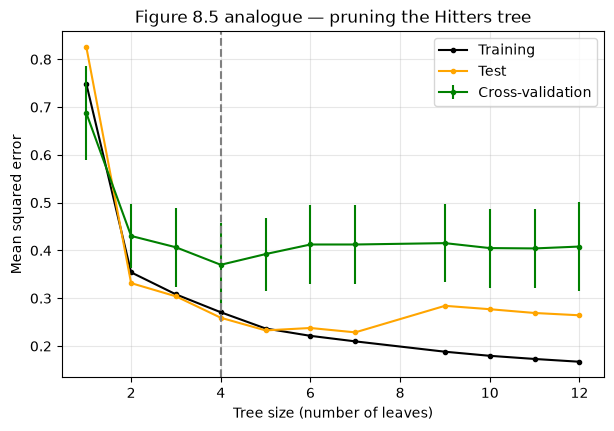

CV-optimal size: 4 leaves (alpha=0.0340), test MSE 0.259
Unpruned tree:   19 leaves, test MSE 0.260


In [7]:
p = prune[prune.n_leaves <= 12]
fig, ax = plt.subplots()
ax.plot(p.n_leaves, p.train, 'k-o', ms=3, label='Training')
ax.errorbar(p.n_leaves, p.cv, yerr=p.cv_se, fmt='-o', ms=3,
            color='green', label='Cross-validation')
ax.plot(p.n_leaves, p.test, '-o', ms=3, color='orange', label='Test')
best = prune.loc[prune.cv.idxmin()]
ax.axvline(best.n_leaves, ls='--', color='grey')
ax.set_xlabel('Tree size (number of leaves)'); ax.set_ylabel('Mean squared error')
ax.set_title('Figure 8.5 analogue — pruning the Hitters tree')
ax.legend(); plt.show()

print(f"CV-optimal size: {int(best.n_leaves)} leaves (alpha={best.alpha:.4f}), "
      f"test MSE {best.test:.3f}")
print(f"Unpruned tree:   {big_tree.get_n_leaves()} leaves, "
      f"test MSE {mse(yh_te, big_tree.predict(Xh_te)):.3f}")

**Read the plot the way the book does.** Training error falls monotonically with size it always will, so it is useless for model selection. The CV curve is a usable stand-in for the test curve: both bottom out at a small tree. That is the whole argument for pruning.

## 1.3 The instability that motivates everything else

The claim in §8.2.1 is that trees have *high variance*: refit on a different random half of the data and you get a different tree. Let's measure it rather than assume it refit on 10 bootstrap samples and look at how much the root split and the predictions move.

In [8]:
roots, preds = [], []
rng = np.random.default_rng(RNG)
for b in range(10):
    idx = rng.choice(len(Xh_tr), len(Xh_tr), replace=True)
    t = DTR(max_depth=3, random_state=RNG).fit(Xh_tr.iloc[idx], yh_tr.iloc[idx])
    roots.append(X_h.columns[t.tree_.feature[0]])
    preds.append(t.predict(Xh_te))

print("root split variable across 10 bootstrap refits:")
print(pd.Series(roots).value_counts().to_string())

preds = np.array(preds)
print(f"\nmean SD of the prediction for a single test point: {preds.std(0).mean():.3f} (log $)")
print(f"MSE of the *average* of the 10 trees: {mse(yh_te, preds.mean(0)):.3f}")
print(f"mean MSE of the 10 trees individually: {np.mean([mse(yh_te, p) for p in preds]):.3f}")

root split variable across 10 bootstrap refits:
CHits     5
CRuns     2
CAtBat    2
CRBI      1

mean SD of the prediction for a single test point: 0.305 (log $)
MSE of the *average* of the 10 trees: 0.175
mean MSE of the 10 trees individually: 0.307


The average of the ten trees beats the average of their individual errors. That is not a coincidence, it is the bias–variance decomposition doing its job and it is **bagging in miniature**.

Formally: for $n$ independent observations each with variance $\sigma^2$, the mean has variance $\sigma^2/n$. Averaging reduces variance. If we had $B$ independent training sets we would compute $\hat f^1,\dots,\hat f^B$ and average them. We don't, so we bootstrap instead.

## 1.4 Classification trees, briefly

Same machinery, different split criterion. RSS is replaced by a node-purity measure, because the classification error rate $E = 1 - \max_k \hat p_{mk}$ is not sensitive enough to grow good trees:

- **Gini index** $\;G = \sum_{k} \hat p_{mk}(1 - \hat p_{mk})$
- **Entropy** $\;D = -\sum_{k} \hat p_{mk}\log \hat p_{mk}$

Both are small when a node is pure. Use Gini/entropy to *grow*, and classification error to *prune* if final accuracy is the goal.

In [9]:
Carseats = load_data('Carseats')
High = np.where(Carseats.Sales > 8, "Yes", "No")

design = MS(Carseats.columns.drop('Sales'), intercept=False)
X_c = design.fit_transform(Carseats)
y_c = High

Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(X_c, y_c, test_size=0.3,
                                              random_state=RNG, stratify=y_c)
print(X_c.shape, "->", Xc_tr.shape, Xc_te.shape)
X_c.head(3)

(400, 11) -> (280, 11) (120, 11)


,CompPrice,Income,Advertising,Population,Price,ShelveLoc[Good],ShelveLoc[Medium],Age,Education,Urban[Yes],US[Yes]
0,138,73,11,276,120,0.0,0.0,42,17,1.0,1.0
1,111,48,16,260,83,1.0,0.0,65,10,1.0,1.0
2,113,35,10,269,80,0.0,1.0,59,12,1.0,1.0


gini     test accuracy: 0.683
entropy  test accuracy: 0.700


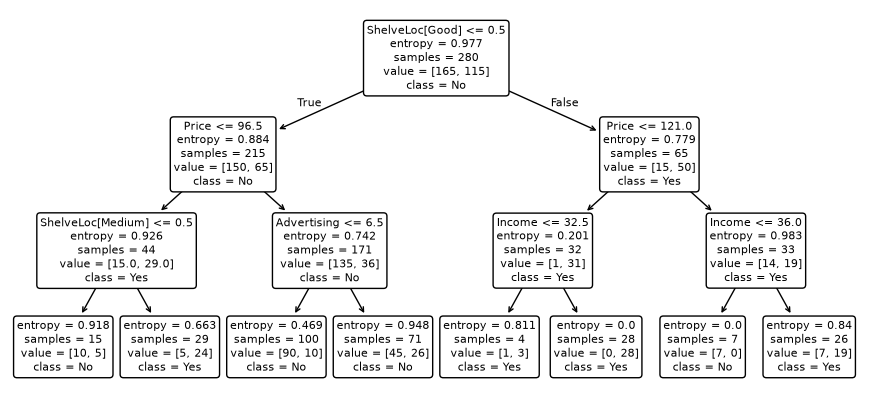

Truth,No,Yes
Predicted,,
No,64,29
Yes,7,20


In [10]:
for crit in ['gini', 'entropy']:
    clf = DTC(criterion=crit, max_depth=3, random_state=RNG).fit(Xc_tr, yc_tr)
    print(f"{crit:8s} test accuracy: {accuracy_score(yc_te, clf.predict(Xc_te)):.3f}")

clf = DTC(criterion='entropy', max_depth=3, random_state=RNG).fit(Xc_tr, yc_tr)
fig, ax = plt.subplots(figsize=(11, 5))
plot_tree(clf, feature_names=list(X_c.columns), class_names=['No', 'Yes'],
          filled=False, rounded=True, fontsize=8, ax=ax)
plt.show()

confusion_table(clf.predict(Xc_te), yc_te)

---

# Part 2: Bagging

## 2.1 What it is

**B**ootstrap **agg**regat**ing**. Draw $B$ bootstrap samples from the training set, fit a deep unpruned tree to each, and average:

$$\hat f_{\text{bag}}(x) = \frac{1}{B}\sum_{b=1}^{B} \hat f^{*b}(x)$$

For classification, take a **majority vote** across the $B$ trees instead.

Two design choices matter and both follow from the bias–variance argument:

- **Grow deep, do not prune.** Each tree should be low-bias / high-variance; averaging kills the variance. Pruning would add bias that averaging cannot remove.
- **$B$ is not a tuning parameter.** Larger $B$ never overfits; it just converges. Pick $B$ large enough that the error curve has flattened (often 100–500).

## 2.2 Training it

Two equivalent routes in scikit-learn. `BaggingRegressor` is the literal implementation; `RandomForestRegressor(max_features=None)` is the same thing (a random forest with $m = p$) and is faster and gives you OOB scoring for free. We use the Boston data from here on.

In [11]:
Boston = load_data('Boston')
X_b = Boston.drop(columns=['medv'])
y_b = Boston['medv']
p = X_b.shape[1]

Xtr, Xte, ytr, yte = train_test_split(X_b, y_b, test_size=0.3, random_state=RNG)
print(f"n_train={len(Xtr)}, n_test={len(Xte)}, p={p}")
print(list(X_b.columns))

n_train=354, n_test=152, p=12
['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'lstat']


In [12]:
# Reference point: a single pruned tree
single = DTR(min_samples_leaf=5, random_state=RNG).fit(Xtr, ytr)
alphas_b = single.cost_complexity_pruning_path(Xtr, ytr).ccp_alphas
grid_tree = GridSearchCV(DTR(min_samples_leaf=5, random_state=RNG),
                         {'ccp_alpha': alphas_b[::3]},
                         cv=KFold(5, shuffle=True, random_state=RNG),
                         scoring='neg_mean_squared_error').fit(Xtr, ytr)
tree_mse = mse(yte, grid_tree.predict(Xte))
RESULTS['Single tree (pruned)'] = tree_mse
print(f"single pruned tree  test MSE = {tree_mse:6.2f}")

single pruned tree  test MSE =  22.67


In [13]:
# Route A - the literal bagging estimator
bag_A = BaggingRegressor(estimator=DTR(random_state=RNG),   # deep, unpruned
                         n_estimators=500,
                         bootstrap=True,
                         oob_score=True,
                         n_jobs=-1,
                         random_state=RNG).fit(Xtr, ytr)

# Route B - a random forest with m = p is bagging
bag_B = RFR(n_estimators=500, max_features=None,
            oob_score=True, n_jobs=-1, random_state=RNG).fit(Xtr, ytr)

print(f"BaggingRegressor        test MSE = {mse(yte, bag_A.predict(Xte)):6.2f}")
print(f"RFR(max_features=None)  test MSE = {mse(yte, bag_B.predict(Xte)):6.2f}")
RESULTS['Bagging'] = mse(yte, bag_B.predict(Xte))

BaggingRegressor        test MSE =  14.96
RFR(max_features=None)  test MSE =  14.61


## 2.3 Out-of-bag error free cross-validation

Each bootstrap sample uses about $1 - (1-1/n)^n \to 1 - e^{-1} \approx 2/3$ of the observations. The remaining third are **out-of-bag** for that tree. Predict observation $i$ using only the ~$B/3$ trees that never saw it, and you get an honest held-out prediction with no extra fitting. With $B$ large, OOB error is essentially leave-one-out CV and it costs nothing.

This is the reason RF/bagging tuning is cheap: you can tune on OOB instead of running a full `GridSearchCV`.

In [14]:
oob_pred = bag_B.oob_prediction_
print(f"OOB  MSE = {mse(ytr, oob_pred):6.2f}   (OOB R^2 = {bag_B.oob_score_:.3f})")
print(f"Test MSE = {mse(yte, bag_B.predict(Xte)):6.2f}")
print(f"Train MSE (optimistic, do not use) = {mse(ytr, bag_B.predict(Xtr)):6.2f}")

frac = 1 - (1 - 1/len(Xtr))**len(Xtr)
print(f"\nexpected fraction of rows in a bootstrap sample: {frac:.3f}  (theory: {1-np.exp(-1):.3f})")

OOB  MSE =  10.35   (OOB R^2 = 0.878)
Test MSE =  14.61
Train MSE (optimistic, do not use) =   1.37

expected fraction of rows in a bootstrap sample: 0.633  (theory: 0.632)


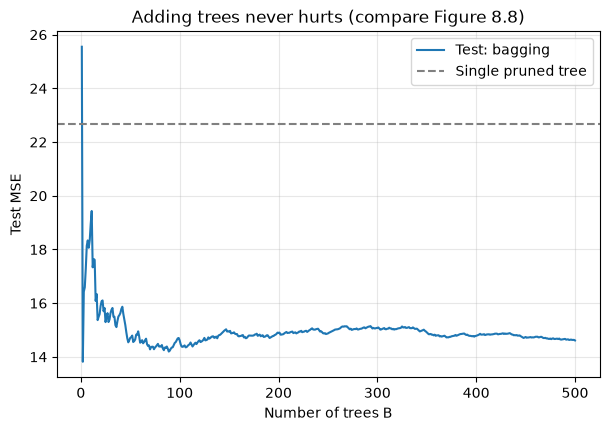

test MSE at B = 10, 50, 100, 500: [18.95 14.71 14.61 14.61]


In [15]:
def error_vs_B(forest, X, y):
    """Test error as a function of the number of trees, by cumulatively averaging
    the per-tree predictions. Works for any bagged/RF regressor."""
    per_tree = np.array([t.predict(np.asarray(X)) for t in forest.estimators_])
    running = np.cumsum(per_tree, axis=0) / np.arange(1, len(per_tree) + 1)[:, None]
    return ((running - np.asarray(y)) ** 2).mean(axis=1)

curve_bag = error_vs_B(bag_B, Xte, yte)

fig, ax = plt.subplots()
ax.plot(np.arange(1, len(curve_bag) + 1), curve_bag, label='Test: bagging')
ax.axhline(tree_mse, ls='--', color='grey', label='Single pruned tree')
ax.set_xlabel('Number of trees B'); ax.set_ylabel('Test MSE')
ax.set_title('Adding trees never hurts (compare Figure 8.8)')
ax.legend(); plt.show()

print("test MSE at B = 10, 50, 100, 500:",
      np.round(curve_bag[[9, 49, 99, 499]], 2))

The curve settles after roughly 100 trees and then stays flat. **This is the diagnostic to run before you spend money on more trees** not a validation curve to minimise.

## 2.4 Interpreting a bagged model

We traded the picture of a single tree for accuracy. What we get back is a *summary* of importance: for regression, the total reduction in RSS attributable to splits on each predictor, averaged over all $B$ trees (for classification, the total reduction in Gini).

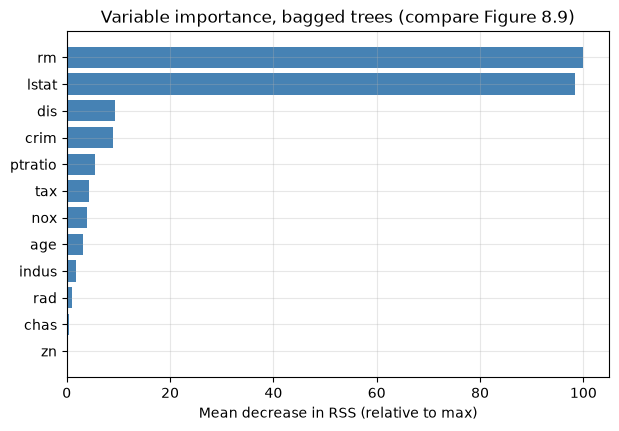

,importance
rm,100.0
lstat,98.4
dis,9.4
crim,9.0
ptratio,5.4


In [16]:
imp = pd.Series(bag_B.feature_importances_, index=X_b.columns).sort_values()
imp_rel = 100 * imp / imp.max()

fig, ax = plt.subplots()
ax.barh(imp_rel.index, imp_rel.values, color='steelblue')
ax.set_xlabel('Mean decrease in RSS (relative to max)')
ax.set_title('Variable importance, bagged trees (compare Figure 8.9)')
plt.show()

imp_rel.sort_values(ascending=False).round(1).to_frame('importance').head()

---

# Part 3: Random forests

## 3.1 What it is, and why the tweak works

Bagging has a hidden flaw. If one predictor dominates, *every* bootstrap tree splits on it at the top, so the $B$ trees look alike. Averaging **correlated** quantities does not reduce variance nearly as much as averaging uncorrelated ones: for $B$ variables each with variance $\sigma^2$ and pairwise correlation $\rho$,

$$\operatorname{Var}\!\left(\bar Z\right) = \rho\sigma^2 + \frac{1 - \rho}{B}\sigma^2$$

The second term vanishes as $B \to \infty$; the first does not. **The correlation $\rho$ is the ceiling on how much bagging can help.**

Random forests attack $\rho$ directly: at *each split*, only a fresh random subset of $m$ predictors is eligible. On average $(p-m)/p$ of splits cannot even see the dominant predictor, so the other predictors get their turn and the trees **decorrelate**.

- $m = p$ → bagging
- $m \approx \sqrt{p}$ → the usual default for classification
- $m \approx p/3$ → the usual default for regression

Small $m$ helps most when predictors are many and correlated. It costs a little bias per tree and buys a lot of decorrelation.

In [17]:
settings = {'m = p (bagging)': None, 'm = p/2': 0.5, 'm = sqrt(p)': 'sqrt'}

forests, curves = {}, {}
for label, mf in settings.items():
    f = RFR(n_estimators=500, max_features=mf, oob_score=True,
            n_jobs=-1, random_state=RNG).fit(Xtr, ytr)
    forests[label] = f
    curves[label] = error_vs_B(f, Xte, yte)
    print(f"{label:16s} OOB MSE = {mse(ytr, f.oob_prediction_):6.2f}   "
          f"test MSE = {mse(yte, f.predict(Xte)):6.2f}")

RESULTS['Random forest'] = mse(yte, forests['m = sqrt(p)'].predict(Xte))

m = p (bagging)  OOB MSE =  10.35   test MSE =  14.61
m = p/2          OOB MSE =   8.56   test MSE =  18.62
m = sqrt(p)      OOB MSE =   8.62   test MSE =  19.65


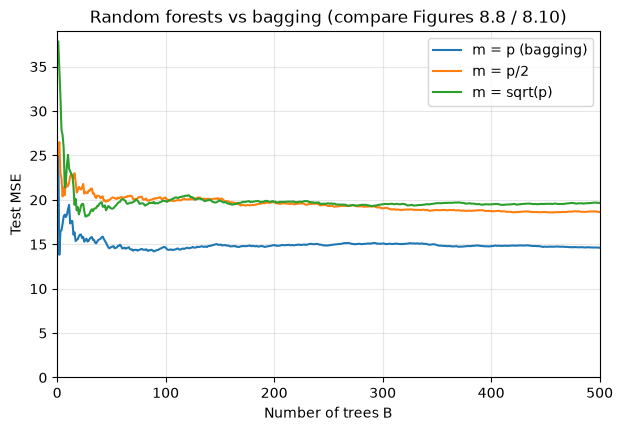

In [18]:
fig, ax = plt.subplots()
for label, c in curves.items():
    ax.plot(np.arange(1, len(c) + 1), c, label=label)
ax.set_xlabel('Number of trees B'); ax.set_ylabel('Test MSE')
ax.set_xlim(0, 500); ax.set_ylim(bottom=0)
ax.set_title('Random forests vs bagging (compare Figures 8.8 / 8.10)')
ax.legend(); plt.show()

**Read the numbers before you read the theory.** On this split, the smaller-$m$ forests have *lower* OOB error than bagging but *higher* test error. Both cannot be right about which model generalises better, and the honest answer is that the disagreement is noise: OOB averages over all 354 training rows (roughly leave-one-out), while the test estimate rests on 152 rows and carries a standard error of several MSE units. Boston also has only 12 predictors, few of them redundant precisely the setting where decorrelation has the least to offer.

Do not resolve this by picking whichever number flatters the method. Resolve it by repeating the split, which we do in Part 6. The theory says small $m$ helps when predictors are **many and correlated** (the gene-expression example in the chapter has p = 500); it does not promise a win on every dataset.

## 3.2 Tuning a random forest

There are only a few knobs, and one of them dominates:

| Parameter | What it does | Sensible search |
|---|---|---|
| `max_features` (m) | decorrelation vs per-tree strength | **the one that matters**: `sqrt`, `log2`, 0.33, 0.5, `None` |
| `min_samples_leaf` | leaf size mild regularisation | 1, 2, 5 |
| `max_depth` | usually leave unlimited | rarely needed |
| `n_estimators` | more is never worse | fix it large (300–1000) |

Tune on **OOB error** when you can it is one fit per configuration instead of `k` fits.

In [19]:
t0 = time.time()
oob_rows = []
for mf in ['sqrt', 'log2', 0.33, 0.5, 0.75, None]:
    for leaf in [1, 2, 5]:
        f = RFR(n_estimators=300, max_features=mf, min_samples_leaf=leaf,
                oob_score=True, n_jobs=-1, random_state=RNG).fit(Xtr, ytr)
        oob_rows.append(dict(max_features=str(mf), min_samples_leaf=leaf,
                             oob_mse=mse(ytr, f.oob_prediction_),
                             test_mse=mse(yte, f.predict(Xte))))
oob_tab = pd.DataFrame(oob_rows).sort_values('oob_mse')
print(f"18 configurations tuned on OOB in {time.time()-t0:.1f}s")
oob_tab.head(6).round(3)

18 configurations tuned on OOB in 15.8s


,max_features,min_samples_leaf,oob_mse,test_mse
9,0.5,1,8.713,19.030
0,sqrt,1,8.737,19.507
6,0.33,1,8.737,19.507
3,log2,1,8.737,19.507
12,0.75,1,9.331,16.361
10,0.5,2,9.496,19.472


In [20]:
# Sanity check that OOB selection agrees with proper k-fold CV
grid_rf = GridSearchCV(RFR(n_estimators=300, n_jobs=-1, random_state=RNG),
                       {'max_features': ['sqrt', 0.33, 0.5, None],
                        'min_samples_leaf': [1, 2, 5]},
                       cv=KFold(5, shuffle=True, random_state=RNG),
                       scoring='neg_mean_squared_error', n_jobs=-1).fit(Xtr, ytr)

print("OOB pick :", oob_tab.iloc[0][['max_features', 'min_samples_leaf']].to_dict())
print("CV  pick :", grid_rf.best_params_)
rf_best = grid_rf.best_estimator_
RESULTS['Random forest (tuned)'] = mse(yte, rf_best.predict(Xte))
print(f"tuned RF test MSE = {RESULTS['Random forest (tuned)']:.2f}")

OOB pick : {'max_features': '0.5', 'min_samples_leaf': 1}
CV  pick : {'max_features': 'sqrt', 'min_samples_leaf': 1}
tuned RF test MSE = 19.51


## 3.3 Interpreting a random forest

Three tools, in increasing order of trustworthiness:

1. **Impurity importance** (`feature_importances_`) free, but *biased*: it inflates continuous and high-cardinality predictors, and it is computed on training data.
2. **Permutation importance** shuffle one column in the **held-out** set and measure how much the score degrades. Model-agnostic and honest, but correlated predictors share credit and can both look unimportant.
3. **Partial dependence / ICE** shows the *shape and direction* of an effect, not just its size. Importance tells you `lstat` matters; PDP tells you higher `lstat` means lower `medv`.

Always report at least (1) and (3). Prefer (2) over (1) when the decision matters.

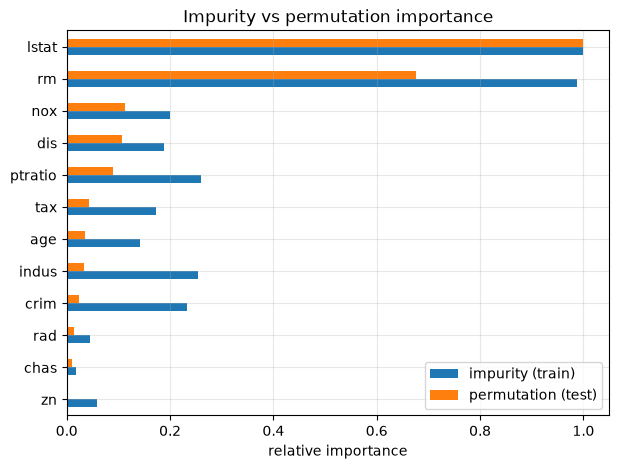

,impurity (train),permutation (test)
lstat,1.000,1.000
rm,0.988,0.675
nox,0.200,0.112
dis,0.189,0.107
ptratio,0.259,0.090


In [21]:
perm = permutation_importance(rf_best, Xte, yte, n_repeats=30,
                              random_state=RNG, n_jobs=-1)

comp = pd.DataFrame({
    'impurity (train)': rf_best.feature_importances_,
    'permutation (test)': perm.importances_mean,
}, index=X_b.columns)
comp = comp / comp.max()          # rescale both to [0,1] so they are comparable

fig, ax = plt.subplots(figsize=(7, 5))
comp.sort_values('permutation (test)').plot.barh(ax=ax)
ax.set_xlabel('relative importance'); ax.set_title('Impurity vs permutation importance')
plt.show()

comp.sort_values('permutation (test)', ascending=False).round(3).head()

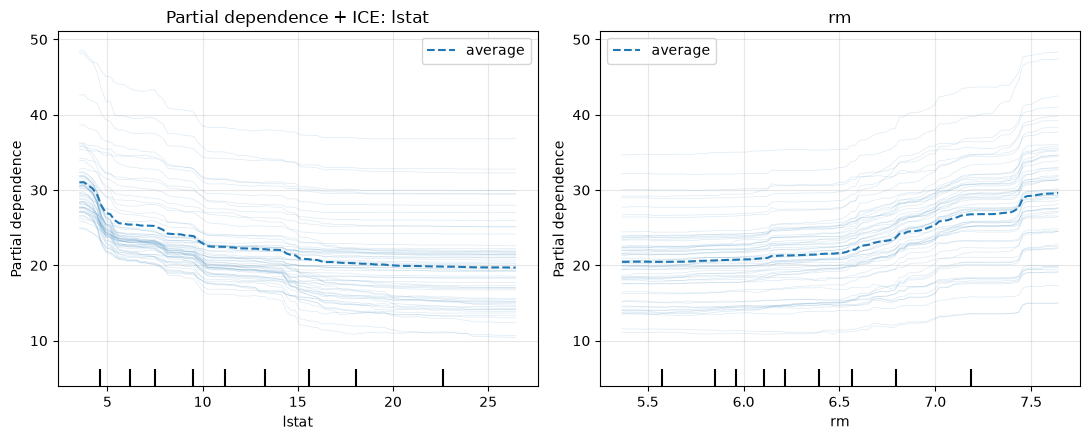

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
PartialDependenceDisplay.from_estimator(rf_best, Xtr, ['lstat', 'rm'],
                                        kind='both', subsample=60,
                                        ice_lines_kw={'alpha': 0.15},
                                        random_state=RNG, ax=ax)
ax[0].set_title('Partial dependence + ICE: lstat')
ax[1].set_title('rm')
plt.tight_layout(); plt.show()

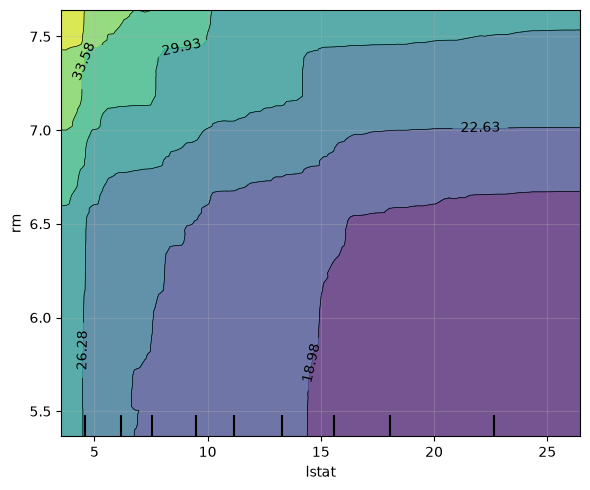

In [23]:
# Two-way partial dependence: does the effect of rm depend on lstat?
fig, ax = plt.subplots(figsize=(6, 5))
PartialDependenceDisplay.from_estimator(rf_best, Xtr, [('lstat', 'rm')], ax=ax)
plt.tight_layout(); plt.show()

## 3.4 Random forest for classification

Identical, with `RandomForestClassifier`: majority vote instead of averaging, Gini instead of RSS for the importance summary. `oob_score_` is accuracy here.

In [24]:
rfc = RFC(n_estimators=500, max_features='sqrt', oob_score=True,
          n_jobs=-1, random_state=RNG).fit(Xc_tr, yc_tr)

print(f"OOB accuracy  = {rfc.oob_score_:.3f}")
print(f"Test accuracy = {accuracy_score(yc_te, rfc.predict(Xc_te)):.3f}")
confusion_table(rfc.predict(Xc_te), yc_te)

OOB accuracy  = 0.804
Test accuracy = 0.808


Truth,No,Yes
Predicted,,
No,63,15
Yes,8,34


---

# Part 4: Boosting

## 4.1 What it is

Bagging and forests fight **variance** by averaging independent trees. Boosting fights **bias** by growing trees **sequentially**, each one fitted to what the current model still gets wrong.

**Algorithm 8.2 (boosting for regression trees).**

1. Set $\hat f(x) = 0$ and $r_i = y_i$ for all $i$.
2. For $b = 1,\dots,B$:
   - fit a tree $\hat f^b$ with $d$ splits to the data $(X, r)$ **the residuals, not $y$**
   - update $\hat f(x) \leftarrow \hat f(x) + \lambda \hat f^b(x)$
   - update $r_i \leftarrow r_i - \lambda \hat f^b(x_i)$
3. Output $\hat f(x) = \sum_{b=1}^{B} \lambda \hat f^b(x)$

No bootstrap anywhere. The whole idea is to **learn slowly**: small trees, shrunk by $\lambda$, each nibbling at the leftover signal. Statistical learning methods that learn slowly tend to generalise well.

## 4.2 The three tuning parameters and the one trap

| Parameter | sklearn name | Effect | Typical |
|---|---|---|---|
| $B$, number of trees | `n_estimators` | **boosting CAN overfit if B is too large** | chosen by CV / early stopping |
| $\lambda$, shrinkage | `learning_rate` | how fast it learns; small $\lambda$ needs large $B$ | 0.01–0.1 |
| $d$, splits per tree | `max_depth` | interaction order; $d=1$ = *stump* = additive model | 1–4 |

$\lambda$ and $B$ trade off against each other almost exactly halve the learning rate, double the trees. Tune them **together**, never one at a time.

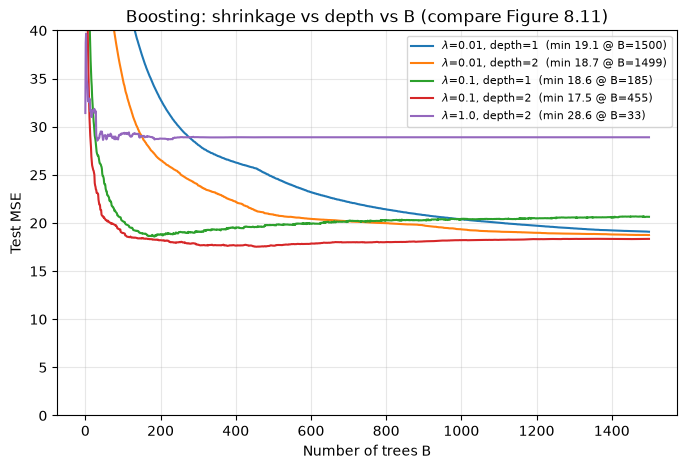

In [25]:
configs = [(0.01, 1), (0.01, 2), (0.1, 1), (0.1, 2), (1.0, 2)]

fig, ax = plt.subplots(figsize=(8, 5))
for lr, d in configs:
    g = GBR(n_estimators=1500, learning_rate=lr, max_depth=d,
            random_state=RNG).fit(Xtr, ytr)
    test_path = np.array([mse(yte, p) for p in g.staged_predict(Xte)])
    ax.plot(test_path, label=f"$\lambda$={lr}, depth={d}  (min {test_path.min():.1f} @ B={test_path.argmin()+1})")

ax.set_xlabel('Number of trees B'); ax.set_ylabel('Test MSE')
ax.set_ylim(0, 40)
ax.set_title('Boosting: shrinkage vs depth vs B (compare Figure 8.11)')
ax.legend(fontsize=8); plt.show()

Look at the $\lambda = 1$ curve: it dives, bottoms out, and then **climbs back up**. That is boosting overfitting the behaviour bagging, forests and BART never show. The slow learners ($\lambda = 0.01$) are still improving at B = 1500 and would need more trees.

Depth-1 stumps fit a purely **additive** model (each term involves one variable). Depth $d$ allows interactions of order up to $d$. That is what `max_depth` really controls here the book calls it the *interaction depth*.

In [26]:
t0 = time.time()
grid_gb = GridSearchCV(
    GBR(n_estimators=1000, random_state=RNG),
    {'learning_rate': [0.01, 0.05, 0.1],
     'max_depth': [1, 2, 3],
     'subsample': [1.0, 0.7]},          # subsample<1 = stochastic gradient boosting
    cv=KFold(5, shuffle=True, random_state=RNG),
    scoring='neg_mean_squared_error', n_jobs=-1).fit(Xtr, ytr)

print(f"grid searched in {time.time()-t0:.1f}s")
print("best params:", grid_gb.best_params_)
print(f"best CV MSE: {-grid_gb.best_score_:.2f}")

gb_best = grid_gb.best_estimator_
RESULTS['Boosting (tuned)'] = mse(yte, gb_best.predict(Xte))
print(f"test MSE:    {RESULTS['Boosting (tuned)']:.2f}")

grid searched in 28.6s
best params: {'learning_rate': 0.05, 'max_depth': 2, 'subsample': 0.7}
best CV MSE: 8.20
test MSE:    17.24


In [27]:
# B was fixed at 1000 above. Pick it properly, by early stopping on a validation split.
gb_es = GBR(n_estimators=5000,
            learning_rate=grid_gb.best_params_['learning_rate'],
            max_depth=grid_gb.best_params_['max_depth'],
            subsample=grid_gb.best_params_['subsample'],
            validation_fraction=0.2, n_iter_no_change=50, tol=1e-4,
            random_state=RNG).fit(Xtr, ytr)

print(f"early stopping chose B = {gb_es.n_estimators_} of 5000")
print(f"test MSE = {mse(yte, gb_es.predict(Xte)):.2f}")

early stopping chose B = 220 of 5000
test MSE = 17.36


In [28]:
# For larger n, use the histogram-based implementation - same algorithm, binned splits
hgb = HGBR(max_iter=1000, learning_rate=0.05, max_depth=3,
           early_stopping=True, validation_fraction=0.2,
           n_iter_no_change=50, random_state=RNG).fit(Xtr, ytr)
stopped = hgb.n_iter_ < 1000
print(f"HistGradientBoosting: {hgb.n_iter_} iterations "
      f"({'stopped early' if stopped else 'hit max_iter'}), "
      f"test MSE = {mse(yte, hgb.predict(Xte)):.2f}")
print("(XGBoost / LightGBM / CatBoost are the same idea with more engineering.)")

HistGradientBoosting: 1000 iterations (hit max_iter), test MSE = 16.20
(XGBoost / LightGBM / CatBoost are the same idea with more engineering.)


### Interpreting a boosted model

Same toolkit as the forest importances plus partial dependence. Two boosting-specific notes:

- With `max_depth=1` the model is additive, so the partial dependence plot **is** the fitted effect, exactly, with no interaction hiding behind it.
- Boosted importances concentrate more than forest importances: because trees are fitted to residuals, once a variable's signal is absorbed, later trees stop splitting on it.

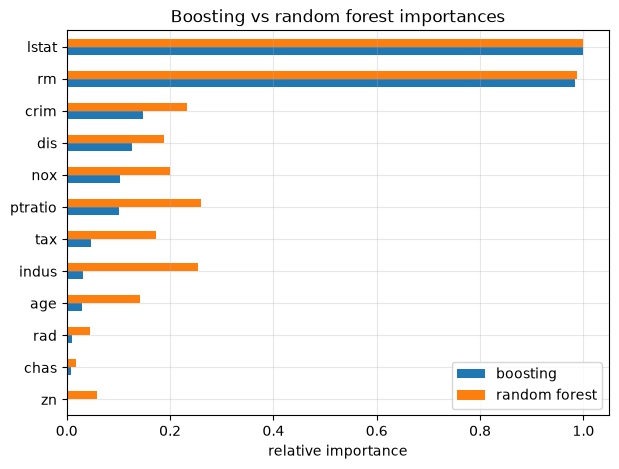

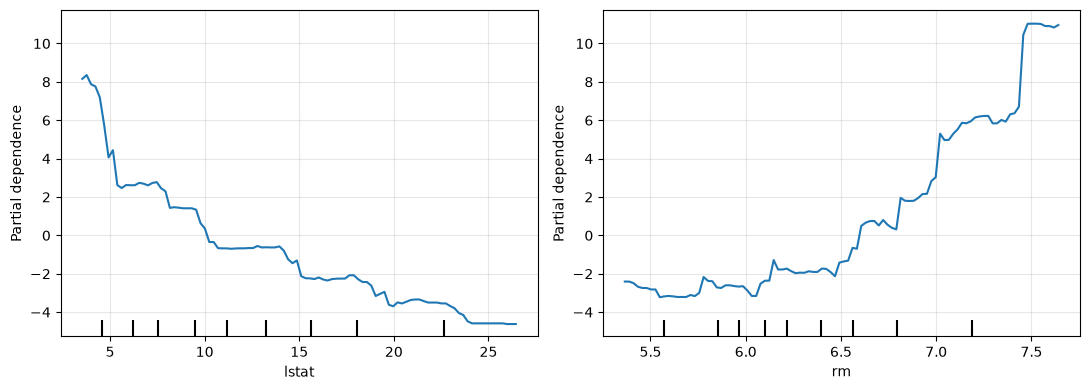

In [29]:
imp_gb = pd.Series(gb_best.feature_importances_, index=X_b.columns)
imp_rf = pd.Series(rf_best.feature_importances_, index=X_b.columns)
side = pd.DataFrame({'boosting': imp_gb / imp_gb.max(),
                     'random forest': imp_rf / imp_rf.max()})

fig, ax = plt.subplots(figsize=(7, 5))
side.sort_values('boosting').plot.barh(ax=ax)
ax.set_xlabel('relative importance'); ax.set_title('Boosting vs random forest importances')
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
PartialDependenceDisplay.from_estimator(gb_best, Xtr, ['lstat', 'rm'], ax=ax)
plt.tight_layout(); plt.show()

---

# Part 5 Bayesian Additive Regression Trees (BART)

## 5.1 What it is

BART borrows from both families. Like boosting, it grows a *sum* of trees that chase the leftover signal. Like bagging, the trees are built with randomness. The novelty is **how new trees are generated**: BART does not fit a fresh tree to the residual, it **perturbs the tree from the previous iteration**, favouring perturbations that improve the fit.

Notation: $K$ trees, $B$ iterations, $\hat f_k^b(x)$ = the $k$th tree at iteration $b$, and $\hat f^b(x) = \sum_{k=1}^{K} \hat f_k^b(x)$.

**Algorithm 8.3.**

1. Initialise every tree to a single root node: $\hat f^1_k(x) = \frac{1}{nK}\sum_i y_i$
2. So $\hat f^1(x) = \frac{1}{n}\sum_i y_i$ the overall mean
3. For $b = 2,\dots,B$; for $k = 1,\dots,K$:
   - compute the **partial residual**, removing all trees but the $k$th:
     $$r_i = y_i - \sum_{k' < k} \hat f^b_{k'}(x_i) - \sum_{k' > k} \hat f^{b-1}_{k'}(x_i)$$
   - obtain $\hat f^b_k$ by randomly **perturbing** $\hat f^{b-1}_k$ grow a branch, prune a branch,
     or change the terminal-node predictions (Figure 8.12) favouring perturbations that fit $r$
4. Average after discarding the first $L$ **burn-in** iterations:
   $$\hat f(x) = \frac{1}{B-L}\sum_{b=L+1}^{B} \hat f^b(x)$$

Perturbing rather than refitting is what stops BART overfitting: it limits how hard we fit the data in any one iteration. Each draw $\hat f^b$ is, formally, a draw from a posterior distribution which is why the whole thing is a Markov chain Monte Carlo algorithm and why the spread of the draws is a genuine **uncertainty interval**, something none of the other three methods gives you.

**Defaults that just work:** $K = 200$, $B = 1000$, $L = 100$. BART is famous for good out-of-box performance with minimal tuning.

In [30]:
from ISLP.bart import BART

# NOTE: ISLP's BART is a pure-Python teaching implementation. B=1000 would take
# several minutes; the values below keep this notebook runnable in ~1 minute.
# For real work use K=200, ndraw=1000, burnin=100 (or the R package `dbarts`).
K, L, B = 200, 50, 150

t0 = time.time()
bart = BART(num_trees=K, burnin=L, ndraw=B, random_state=RNG).fit(Xtr, ytr)
print(f"fitted {K} trees x {L}+{B} iterations in {time.time()-t0:.1f}s")

Xte32 = np.asarray(Xte, dtype=np.float32)
yhat_bart = bart.predict(Xte32)
RESULTS['BART'] = mse(yte, yhat_bart)
print(f"BART test MSE = {RESULTS['BART']:.2f}")

fitted 200 trees x 50+150 iterations in 38.1s
BART test MSE = 20.23


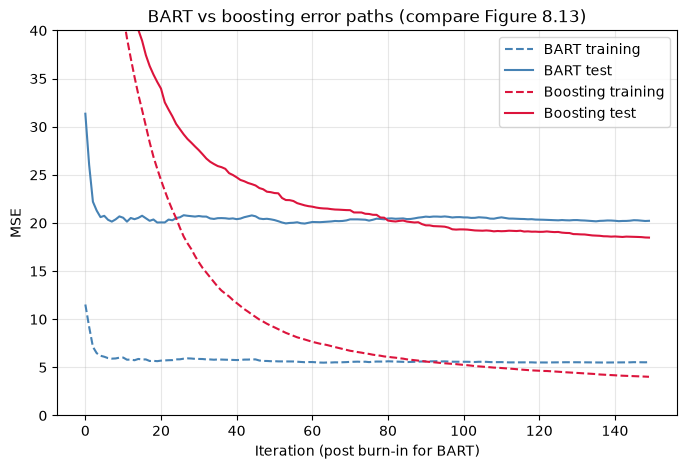

In [31]:
# Error as a function of iteration: the burn-in, then a flat line (compare Figure 8.13)
staged_te = bart.staged_predict(Xte32)                       # running posterior mean
staged_tr = bart.staged_predict(np.asarray(Xtr, dtype=np.float32))

err_te = ((staged_te - np.asarray(yte)) ** 2).mean(1)
err_tr = ((staged_tr - np.asarray(ytr)) ** 2).mean(1)

gb_path_tr = np.array([mse(ytr, p) for p in gb_best.staged_predict(Xtr)])
gb_path_te = np.array([mse(yte, p) for p in gb_best.staged_predict(Xte)])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(err_tr, label='BART training', color='steelblue', ls='--')
ax.plot(err_te, label='BART test', color='steelblue')
ax.plot(gb_path_tr[:len(err_tr)], label='Boosting training', color='crimson', ls='--')
ax.plot(gb_path_te[:len(err_tr)], label='Boosting test', color='crimson')
ax.set_xlabel('Iteration (post burn-in for BART)'); ax.set_ylabel('MSE')
ax.set_ylim(0, 40)
ax.set_title('BART vs boosting error paths (compare Figure 8.13)')
ax.legend(); plt.show()

Note the gap between BART's training and test curves: small. The perturbation scheme largely avoids overfitting on its own. The boosting training curve keeps falling while its test curve flattens or turns the signature of a model fitting harder than the signal supports.

## 5.2 The thing only BART gives you: posterior uncertainty

Every post-burn-in draw $\hat f^b(x)$ is a plausible fitted function. Their spread at a point $x$ is a credible interval for the prediction. We recover the individual draws from the running mean that `staged_predict` returns.

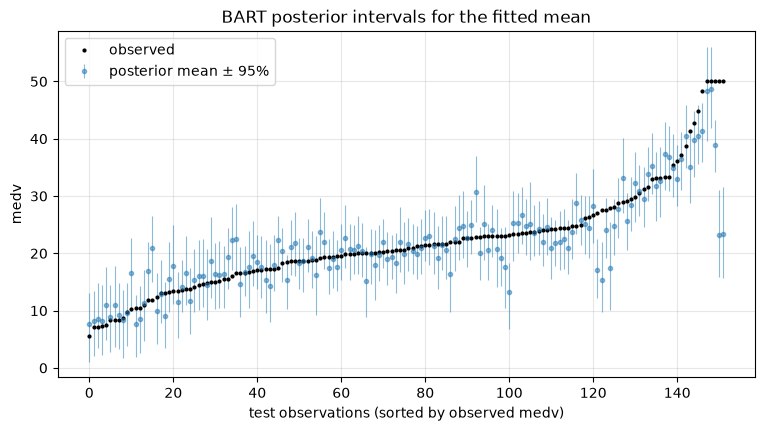

observations inside the interval: 90.8%
(these are intervals for f(x), not prediction intervals for a new y - they are narrower than 95% coverage of raw observations by design)


In [32]:
def posterior_draws(staged):
    """ISLP's staged_predict returns the running average of the draws;
    de-cumulate it to recover the individual posterior draws."""
    weights = np.arange(1, staged.shape[0] + 1)[:, None]
    sums = staged * weights
    return np.diff(np.vstack([np.zeros((1, staged.shape[1])), sums]), axis=0)

draws = posterior_draws(staged_te)             # (B, n_test)
lo, hi = np.percentile(draws, [2.5, 97.5], axis=0)
mid = draws.mean(0)

order = np.argsort(np.asarray(yte))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.errorbar(range(len(yte)), mid[order],
            yerr=[mid[order] - lo[order], hi[order] - mid[order]],
            fmt='o', ms=3, alpha=0.5, elinewidth=0.8, label='posterior mean ± 95%')
ax.plot(range(len(yte)), np.asarray(yte)[order], 'k.', ms=4, label='observed')
ax.set_xlabel('test observations (sorted by observed medv)'); ax.set_ylabel('medv')
ax.set_title('BART posterior intervals for the fitted mean')
ax.legend(); plt.show()

inside = ((np.asarray(yte) >= lo) & (np.asarray(yte) <= hi)).mean()
print(f"observations inside the interval: {inside:.1%}")
print("(these are intervals for f(x), not prediction intervals for a new y - "
      "they are narrower than 95% coverage of raw observations by design)")

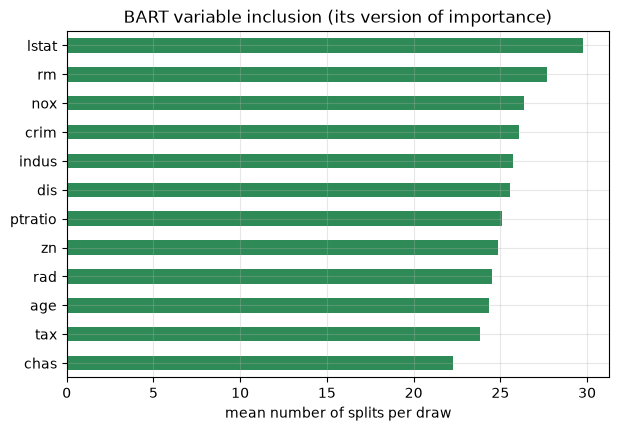

lstat    29.79
rm       27.69
nox      26.37
crim     26.08
indus    25.71
dtype: float64

In [33]:
# Variable inclusion: how often each predictor is split on, averaged over draws
vi = pd.Series(np.asarray(bart.variable_inclusion_).mean(0), index=X_b.columns)

fig, ax = plt.subplots(figsize=(7, 4.5))
vi.sort_values().plot.barh(ax=ax, color='seagreen')
ax.set_xlabel('mean number of splits per draw')
ax.set_title('BART variable inclusion (its version of importance)')
plt.show()

vi.sort_values(ascending=False).round(2).head()

### Tuning BART

Barely necessary, which is the point:

- **K (`num_trees`)** 200 is standard. More trees = more capacity, each contributing less.
- **B (`ndraw`)** as many as you can afford; more draws = smoother posterior. 1000 is typical.
- **L (`burnin`)** 100 is typical. Check convergence by plotting the error path (as above) and
  discarding everything before it flattens.
- $\sigma$ and split priors exist but the defaults are well tested.

One caution on the inclusion plot above: with only 150 draws the counts are noisy and fairly flat, because 200 trees have to share the splits. Variable inclusion is a weaker importance signal than a forest's permutation importance treat it as a screening device, not a ranking.

If you need BART seriously (large n, classification, or proper posterior inference), use `dbarts`/`BayesTree` in R or `bartpy`/`PyMC-BART` in Python ISLP's version is for teaching.

---

# Part 6: Head to head

## 6.1 One split (the numbers we accumulated above)

,Test MSE,RMSE
Bagging,14.61,3.82
Boosting (tuned),17.24,4.15
Random forest (tuned),19.51,4.42
Random forest,19.65,4.43
BART,20.23,4.50
Single tree (pruned),22.67,4.76


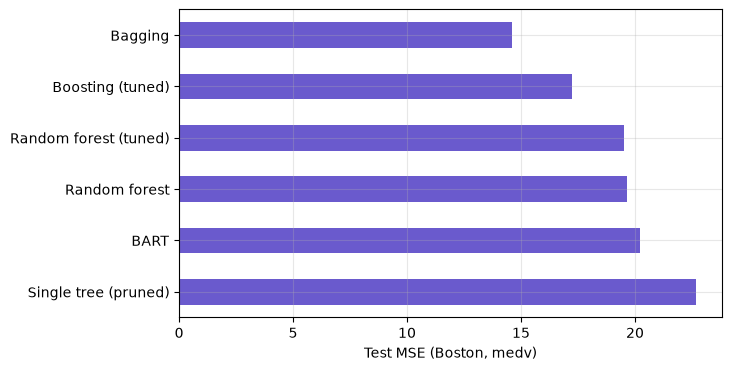

In [34]:
summary = (pd.Series(RESULTS, name='Test MSE')
             .to_frame()
             .assign(RMSE=lambda d: np.sqrt(d['Test MSE']))
             .sort_values('Test MSE'))
display(summary.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
summary['Test MSE'].sort_values(ascending=False).plot.barh(ax=ax, color='slateblue')
ax.set_xlabel('Test MSE (Boston, medv)')
plt.show()

Do not over-read small differences on a 152-row test set the standard errors overlap heavily. The book makes the same caveat about Figure 8.11. The robust conclusion is the large one: **every ensemble beats the single tree by a wide margin**. BART is also handicapped here: it is
fitted with 150 draws to keep this notebook runnable, where the recommended B = 1000 would typically close much of its gap.

## 6.2 The same comparison over 10 random splits

A single train/test split is one draw from a noisy distribution, and Part 3 gave us a concrete reason to distrust it: OOB and test error ranked bagging and the random forest in opposite orders.
Repeating the split is the cheapest way to find out which ordering was real. (BART is excluded here only because the teaching implementation is too slow to refit ten times.)

In [35]:
def compare_once(seed):
    Xa, Xz, ya, yz = train_test_split(X_b, y_b, test_size=0.3, random_state=seed)
    models = {
        'Single tree (unpruned)': DTR(random_state=RNG),
        'Bagging (m=p)':          RFR(n_estimators=300, max_features=None, n_jobs=-1, random_state=RNG),
        'RF (m=sqrt(p))':         RFR(n_estimators=300, max_features='sqrt', n_jobs=-1, random_state=RNG),
        'RF (m=p/2)':             RFR(n_estimators=300, max_features=0.5, n_jobs=-1, random_state=RNG),
        'Boosting':               GBR(n_estimators=500, learning_rate=0.05, max_depth=3,
                                      subsample=0.7, random_state=RNG),
    }
    return {name: mse(yz, m.fit(Xa, ya).predict(Xz)) for name, m in models.items()}

t0 = time.time()
reps = pd.DataFrame([compare_once(s) for s in range(10)])
print(f"10 splits x 5 models in {time.time()-t0:.1f}s")

rep_summary = pd.DataFrame({'mean test MSE': reps.mean(),
                            'SD across splits': reps.std(),
                            'SE of the mean': reps.std() / np.sqrt(len(reps))})
display(rep_summary.sort_values('mean test MSE').round(2))

10 splits x 5 models in 28.9s


,mean test MSE,SD across splits,SE of the mean
Boosting,10.17,2.09,0.66
RF (m=p/2),11.87,2.86,0.90
RF (m=sqrt(p)),11.99,2.96,0.94
Bagging (m=p),12.64,2.67,0.84
Single tree (unpruned),26.10,6.74,2.13


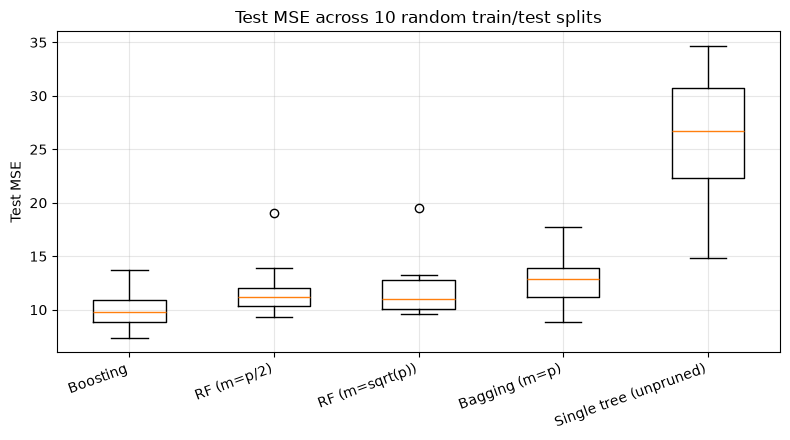

In [39]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order = reps.mean().sort_values().index
ax.boxplot([reps[c] for c in order], vert=True, 
           #labels=order
           )
ax.set_ylabel('Test MSE'); ax.set_xticklabels(order, rotation=20, ha='right')
ax.set_title('Test MSE across 10 random train/test splits')
plt.tight_layout(); plt.show()

Now the picture is stable enough to talk about. The spread **within** each method across splits is comparable to the gaps **between** methods which is exactly why a single split cannot settle the bagging-vs-forest question, and why the chapter hedges its own figure captions with "the standard errors are around 0.02, making none of these differences significant".

If you report ensemble comparisons in a paper, report them like this table, not like a single
number.

## 6.3 The classification versions, side by side

In [40]:
clf_models = {
    'Single tree':   DTC(max_depth=3, random_state=RNG),
    'Bagging':       RFC(n_estimators=500, max_features=None, n_jobs=-1, random_state=RNG),
    'Random forest': RFC(n_estimators=500, max_features='sqrt', n_jobs=-1, random_state=RNG),
    'Boosting':      GBC(n_estimators=500, learning_rate=0.05, max_depth=2, random_state=RNG),
}

rows = []
for name, m in clf_models.items():
    m.fit(Xc_tr, yc_tr)
    rows.append(dict(model=name,
                     test_accuracy=accuracy_score(yc_te, m.predict(Xc_te))))
pd.DataFrame(rows).set_index('model').round(3)

,test_accuracy
model,
Single tree,0.683
Bagging,0.767
Random forest,0.808
Boosting,0.858


BART as presented in ISLP is regression-only; probit-BART for classification exists but is outside the chapter's scope (and is not in `ISLP.bart`).

---

# Part 7 Cheat sheet

### Choosing

- **Need a picture you can show a non-expert?** Single pruned tree. Accept the accuracy loss.
- **Want strong accuracy with almost no tuning?** Random forest. Set `n_estimators=500`, tune `max_features` on OOB, ship it.
- **Want the best possible accuracy and you can afford a search?** Boosting (in practice XGBoost/LightGBM). Budget for tuning `learning_rate` × `n_estimators` × `max_depth`.
- **Want uncertainty quantification for free?** BART.
- **Is the truth roughly linear?** Use a linear model §8.1.3 is explicit that trees lose in that regime. Trees win when the boundary is non-linear and axis-aligned splits can approximate it.

### The failure modes to watch

1. **Tuning boosting's `n_estimators` last, in isolation.** It is entangled with `learning_rate`.
2. **Trusting `feature_importances_`.** Impurity importance is biased toward continuous and high-cardinality predictors, and it is computed in-sample. Cross-check with permutation importance on held-out data.
3. **Reading importance as causation.** It ranks *usefulness to this model*, nothing more. Correlated predictors split the credit arbitrarily.
4. **Preprocessing outside a Pipeline.** Trees need no scaling, but if you impute or encode, do it inside a `Pipeline` so cross-validation stays honest.
5. **Using OOB error for boosting.** OOB is a bagging concept; there is no bootstrap in boosting. Use a validation split or CV.
6. **Growing shallow trees for bagging/RF.** They need to be deep and unpruned the averaging is what handles the variance.

### Reproducing this on your own data

```python
X, y = ...                                   # numeric or one-hot encoded predictors
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0)

rf = RFR(n_estimators=500, oob_score=True, n_jobs=-1, random_state=0).fit(Xtr, ytr)
print(mse(ytr, rf.oob_prediction_))          # honest error estimate, no CV needed

grid = GridSearchCV(GBR(n_estimators=1000, random_state=0),
                    {'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [1, 2, 3]},
                    cv=5, scoring='neg_mean_squared_error', n_jobs=-1).fit(Xtr, ytr)

perm = permutation_importance(grid.best_estimator_, Xte, yte, n_repeats=30, random_state=0)
```

### Exercises worth doing next

1. Re-run Part 3 with `max_features` swept finely from 1 to p and plot test MSE against m. Where is
   the minimum, and does it match $\sqrt{p}$ or $p/3$?
2. Add 20 pure-noise columns to `Boston` and repeat. Which method degrades least, and why does that
   follow from the theory?
3. Set `max_depth=1` in boosting and confirm the fitted model is exactly additive by comparing the
   sum of individual partial dependence curves against the model's predictions.
4. Increase BART's `ndraw` to 500 and check whether the posterior intervals narrow and whether
   test error moves at all.